# Module 2 / Week 1 — DETR from scratch

**Goal:** build a Transformer-based object detector from scratch, learn end-to-end *without* anchor boxes or non-maximum suppression.

**This week's reading:**
- Carion et al. — *End-to-End Object Detection with Transformers* (2020) — https://arxiv.org/abs/2005.12872
- Reference implementation: [facebookresearch/detr](https://github.com/facebookresearch/detr) — read `models/detr.py`, `models/matcher.py`, `models/transformer.py`

**What you should be able to do by the end of the week:**
1. Explain — in plain English — why DETR doesn't need NMS or anchor boxes.
2. Describe what an *object query* is and how N queries → N predictions works.
3. Explain bipartite matching with the Hungarian algorithm and why it makes set prediction differentiable.
4. Implement, end-to-end, a small DETR that detects objects on a toy dataset (single GPU or CPU).
5. Visualize the decoder's cross-attention to see which image regions each query attends to.

**Time budget:** ~1 week. Read paper day 1, build days 2–5, train + analyze days 6–7.

## Why DETR — the conceptual pivot

Pre-DETR detectors (Faster R-CNN, RetinaNet, YOLO) all share a basic recipe:

1. Generate **anchor boxes** at many scales/ratios at every spatial location.
2. For each anchor, predict whether it contains an object + a refinement of the box.
3. Apply **non-maximum suppression (NMS)** to remove redundant detections.

DETR throws all of this out. Instead:

1. Encode the image with a CNN + Transformer encoder → spatial feature tokens.
2. Use N **learned object queries** (e.g. 100) as decoder inputs.
3. Each query, via cross-attention, attends to the image and produces *one* prediction (class + box).
4. **Bipartite matching** between the N predictions and the M ground-truth objects assigns each prediction a target. Unmatched predictions are trained to predict the special class *"no object"*.

No anchors. No NMS. Set prediction, end-to-end differentiable.

### Paper highlights

* "Previous methods address this set prediction task in an indirect ay, by defining surrogate regression and classification problems on a large set of proposals, anchors, or window centers. Their performance is significantly influenced by postprocssing steps to collpase near-duplicate predictions, by the design of the anchor sets and by the heuristics that assign target boxes to anchors."
* "We propose a direct set prediction approach to bypass surrogate tasks."
* "We streamline the training piepleine by viewing object detection as a direct set prediction problem. We adpot an encoder-decoder architecture based on transformers, which explicitly model all pairwise interations between elements in a sequence, make these architectures particularly suitable for specific contraints of set prediction such as removing duplicate predictions."
* "Our matching loss fucntion uniquely assigns a prediction to a ground truth object and is invariant to permutation of predicted objects, so we can emit them in parallel."
* 

**Q.** Before you read the paper, write what you think will be hard about this. Where might it fail?

_..._

## Architecture in one diagram

```
  image [B, 3, H, W]
         │
         ▼
   ┌─────────────┐
   │  Backbone   │  (ResNet-50, frozen or fine-tuned)
   └─────────────┘
         │
  features [B, C, H/32, W/32]
         │
  1×1 conv → [B, d_model, H/32, W/32]
         │
  flatten + 2D positional encoding
         │
  tokens [B, HW/1024, d_model]
         │
         ▼
   ┌─────────────┐
   │  Encoder    │  (6 layers self-attention)
   └─────────────┘
         │
  memory [B, HW/1024, d_model]
         │
         ▼
   ┌──────────────┐    ◄──  N learned object queries [N, d_model]
   │   Decoder    │
   │  (6 layers:  │
   │   self-attn  │
   │   cross-attn │
   │   FFN)       │
   └──────────────┘
         │
  decoder_out [B, N, d_model]
         │
    ┌────┴────┐
    ▼         ▼
  class_head bbox_head
  [B, N, K+1] [B, N, 4]
```

You'll build each block in the cells below. Read the corresponding section of the paper before coding each block.

**Symbols you'll see throughout:**
- `B` = batch size
- `d_model` = transformer hidden dim, e.g. 256
- `N` = number of object queries, e.g. 100
- `K` = number of classes (not counting "no object"); for COCO, K=91
- `H, W` = input image height/width

## Setup

In [545]:
import math
from typing import List, Tuple, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


### Dataset choice

Full COCO is overkill for a from-scratch learning exercise. Three options:

1. **COCO val2017** (~5k images, 80 classes) — realistic but training is slow.
2. **Pascal VOC** (~16k images, 20 classes) — classic, faster.
3. **Toy synthetic dataset** — generate colored shapes on a black background. Trains in minutes, lets you isolate "does my architecture work at all."

**Recommendation:** start with option 3 to debug the implementation, then move to option 2 once it works.


In [546]:
# TODO — build a tiny synthetic detection dataset
# Generate images with K random colored shapes (rectangles) on a black background.
# Return: (image [3, H, W], targets {'boxes': [M, 4] in cxcywh normalized [0,1], 'labels': [M] in [1, K]})
# Hint: class 0 is reserved for 'no object' — keep your real classes in [1, K].

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def make_synthetic_sample(H=224, W=224, K=5, min_objects=1, max_objects=8):
    """Generate one synthetic detection sample.

    Returns:
        image:   [3, H, W] float tensor in [0, 1]
        targets: {'boxes':  [M, 4] cxcywh normalized to [0, 1],
                  'labels': [M] long tensor with values in [1, K]}
    """
    # One distinct color per class. class i -> palette[i-1]
    palette = torch.tensor([
        [1.0, 0.0, 0.0],  # red
        [0.0, 1.0, 0.0],  # green
        [0.0, 0.0, 1.0],  # blue
        [1.0, 1.0, 0.0],  # yellow
        [1.0, 0.0, 1.0],  # magenta
        [0.0, 1.0, 1.0],  # cyan
        [1.0, 0.5, 0.0],  # orange
        [0.5, 0.0, 1.0],  # purple
    ])[:K]
    assert K <= len(palette), "extend the palette if you want more classes"

    image = torch.zeros(3, H, W)
    M = np.random.randint(min_objects, max_objects + 1)

    boxes, labels = [], []
    for _ in range(M):
        cls = np.random.randint(1, K + 1)            # real classes in [1, K]
        w = np.random.randint(W // 10, W // 3)
        h = np.random.randint(H // 10, H // 3)
        x1 = np.random.randint(0, W - w)
        y1 = np.random.randint(0, H - h)
        x2, y2 = x1 + w, y1 + h

        image[:, y1:y2, x1:x2] = palette[cls - 1][:, None, None]

        cx = (x1 + x2) / 2 / W
        cy = (y1 + y2) / 2 / H
        boxes.append([cx, cy, w / W, h / H])
        labels.append(cls)

    targets = {
        'boxes':  torch.tensor(boxes,  dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.long),
    }
    return image, targets

def visualize(image, targets, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    H, W = image.shape[1:]
    ax.imshow(image.permute(1, 2, 0).numpy())
    for box, label in zip(targets['boxes'], targets['labels']):
        cx, cy, bw, bh = box.tolist()
        x1, y1 = (cx - bw / 2) * W, (cy - bh / 2) * H
        ax.add_patch(patches.Rectangle(
            (x1, y1), bw * W, bh * H,
            linewidth=2, edgecolor='white', facecolor='none'))
        ax.text(x1, y1 - 4, f'cls {label.item()}',
                color='white', fontsize=9,
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    ax.axis('off')
    return ax




class ToyDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples: int = 1000, image_size: int = 128, min_objects: int =1, max_objects: int = 5, num_classes: int = 3):
        self.num_samples = num_samples
        self.image_size = image_size
        self.max_objects = max_objects
        self.num_classes = num_classes
        self.images, self.targets = [], []
        for _ in range(num_samples):
            img, tgt = make_synthetic_sample(
                H=image_size, W=image_size,
                K=num_classes, min_objects=1, max_objects=max_objects,
            )
            self.images.append(img)
            self.targets.append(tgt)
        self.images = torch.stack(self.images) 
    def __len__(self):
       return len(self.images)
    def __getitem__(self, idx: int):
        return self.images[idx], self.targets[idx]


In [547]:
toy_data = ToyDetectionDataset(num_samples=1000, image_size=128, min_objects=1, max_objects=5, num_classes=3)

<Axes: >

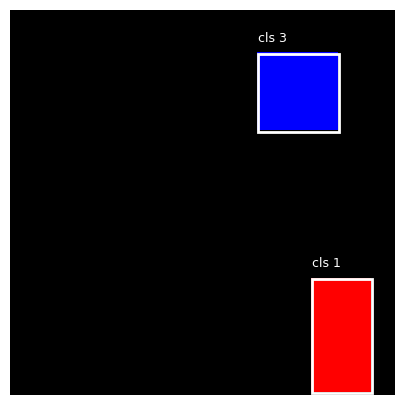

In [548]:
sample, sample_target = toy_data[-19]
visualize(sample, sample_target)

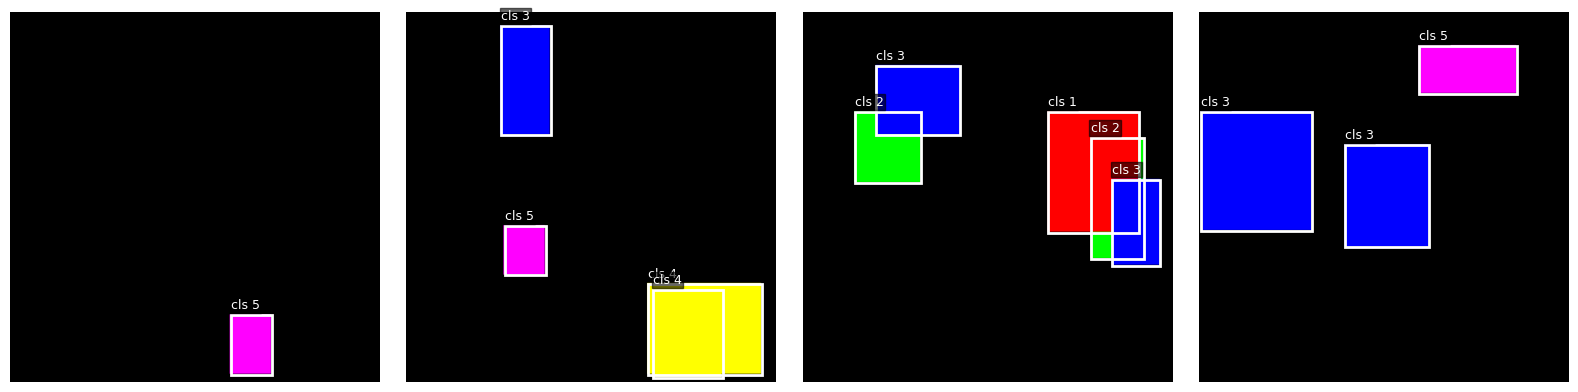

In [549]:
# plot the images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax in axes:
    img, tgt = make_synthetic_sample(K=5)
    visualize(img, tgt, ax)
plt.tight_layout()
plt.show()

## Step 1 — Backbone

The backbone is a standard CNN (ResNet-50 in the paper). It produces a feature map at ~1/32 spatial resolution: `[B, 2048, H/32, W/32]`. A 1×1 conv projects 2048 → `d_model` (=256).

For from-scratch implementation, you have two choices:
- Use `torchvision.models.resnet50(pretrained=True)` and strip the last layers.
- Use a smaller backbone (ResNet-18 or even just a few conv layers) for the toy dataset.

**Q.** Why is the backbone usually pretrained (ImageNet) rather than trained from scratch? What if your dataset is OOD for ImageNet?

_..._

In [550]:
from torchvision import models, transforms
# TODO — Backbone
# 1. Wrap a torchvision ResNet, return the C5 feature map.
# 2. Apply a 1x1 conv to project from 2048 (resnet50) or 512 (resnet18) to d_model.
# 3. Forward should accept [B, 3, H, W] and return [B, d_model, H', W'].

class Backbone(nn.Module):
    def __init__(self, d_model: int = 256, name: str = 'resnet50'):
        super().__init__()
        backbone_fn = getattr(models, name)
        self.resnet = backbone_fn(weights='DEFAULT')
        c5_channels = self.resnet.fc.in_features
        self.body = nn.Sequential(*list(self.resnet.children())[:-2])
        self.projection  = nn.Conv2d(in_channels = c5_channels, out_channels = d_model, kernel_size=(1,1))
        

    def forward(self, x: Tensor) -> Tensor:
        x = self.body(x)
        x = self.projection(x)
        return x


In [551]:
bb = Backbone(d_model=256, name='resnet50')

In [552]:
out = bb(sample.unsqueeze(0))
out.flatten(2).transpose(2,1).shape # need to flatten so the transfoer will get 16 tokens of dim256

torch.Size([1, 16, 256])

## quick understanding of what we pass to the transformer

* so now we have a tensor of shape  `[1, 16, 256]`. We get this from the ResNet backbone. 
* So to understand what these 'tokens' are, we can take a look at the CNN stride and revisit receptive fields.
* The effective stride is 32 pixels. So this is the spatial spacing between adjacent output cells in input-space terms for the cnn. This resnet will downsample by 32 because of the stride=2 operations along the way. 

```

  Input         conv1   maxpool   layer2   layer3   layer4
  128×128  →    64×64 →  32×32 →  16×16 →   8×8   →   4×4
                /2       /2        /2       /2        /2     (cumulative /32)
```

So the 'token; we receive in positin one comes from the spatial cell (0,0), centered around that input position, so top-left of the image. Adjacent cells correposnd to 32-pixel steps in the input. 

* receptive field comes into play here though, because spatial cell (0,0) can actually contain information about more that just that input space grid. Receptive field here is the actual region of the input that can influence a single output cell. Each conv layer grows the receptive field. For a resnet18 last layer output, in theory the receptive field is roughly 150 pixels. 
* Each output cell we feed the transformer is centered in a 32-pixel grid, but each cell seems a much larger neighborhood. 

So in summary:

Each output token:
  - Is centered at a specific input location (every 32 pixels).
  - Is most strongly informed by what's at and near that center.
  - But also has access to broader context via the receptive field.

## Step 2 — 2D positional encoding

The transformer is permutation-invariant — it has no idea where each spatial token sits in the image. We add a **2D sinusoidal positional encoding** that gives every spatial location a unique signature.

Different from the 1D PE in the original Transformer paper. The 2D version splits the channels in half: one half encodes the row (y), the other encodes the column (x), each with sinusoidal frequencies.

**Q.** Why sinusoidal and not learned positional embeddings here? (Hint: input image sizes vary; sinusoidal generalizes to unseen sizes.)

_..._

In [553]:
# TODO — 2D sinusoidal positional encoding
# Given a feature map [B, C, H, W], produce a positional encoding [B, C, H, W] (or [B, H*W, C] after flatten).
# Standard recipe:
#   - half the channels encode y position with sin/cos at log-spaced frequencies
#   - the other half encode x position similarly
#   - frequencies typically: 10000^(2i/d) for i in [0, d/2)

class PositionalEncoding2D(nn.Module):
    def __init__(self, d_model: int = 256, temperature: float = 10000.0):
        super().__init__()
        assert d_model % 4 == 0, 'd_model must be divisible by 4 (half for x, half for y, each with sin+cos)'
        self.d_model = d_model
        self.temperature = temperature
 


    def forward(self, x: Tensor) -> Tensor:
        B, C, H, W = x.shape
        device = x.device
        num_freqs = self.d_model // 4
        freqs = self.temperature ** (2 * torch.arange(num_freqs, device=device).float() / (self.d_model // 2))
        y_pos = torch.arange(H, device=device).float()
        x_pos = torch.arange(W, device=device).float()

        y_div = y_pos[:, None] / freqs[None, :]   # [H, d_model/4]
        x_div = x_pos[:, None] / freqs[None, :]   # [W, d_model/4]
        y_emb = torch.stack([y_div.sin(), y_div.cos()], dim=-1).flatten(-2)  # [H,d_model/2]
        x_emb = torch.stack([x_div.sin(), x_div.cos()], dim=-1).flatten(-2)  # [W,d_model/2]
        
        # Broadcast to a full [H, W, d_model] grid
        y_grid = y_emb[:, None, :].expand(H, W, -1)   # [H, W, d_model/2]
        x_grid = x_emb[None, :, :].expand(H, W, -1)   # [H, W, d_model/2]
        pe = torch.cat([y_grid, x_grid], dim=-1)       # [H, W, d_model]
        pe = pe.permute(2, 0, 1).unsqueeze(0).expand(B, -1, -1, -1)
        # x: [B, C, H, W] (just used for shape, contents ignored)
        # returns: [B, C, H, W] positional encoding
        return pe 


### What are these positional embeddings doing?
* remember, transformers are permutation-invariant, meaning id we shuffle the order of the input tokens, we will get a shuffled output. We need to give it a sense of order in the inputs.
* for grids of images, position obviously matters (actually in sequences of text position matters as well)
* We can inject position information into the tokens themselves so attentinon can leverage that info.
* If we can add a deterministic, position-dependent vector to each token's embedding, then we have given the model that information.

After, we get: `token_at_position_p = content_embedding + PE(p)`

So now, say we have two tokens that have identical embedding information, by adding `PE(p)`, now they have different information, and the attention step can use that to attend by position. 

For images, each token has a 2D position (y, x) — row and column. We want PE such that:

  - Two tokens in the same row but different columns differ in the x direction.
  - Two tokens in the same column but different rows differ in the y direction.
  - The model can learn separate "attend along rows" and "attend along columns" behaviors.

* Addition doesn't corrupt features because:
  *  (a) the 256-d space is big enough for the network to disentangle them via learned projections, 
  *  (b) PE values are bounded and structured, 
  *  and (c) DETR specifically adds PE to Q and K but NOT to V. So position info shapes the attention pattern (who attends to whom) without ever entering the aggregated content (what gets passed along). 
  *  The careful ResNet features flow through V unaltered --> the PE acts as a routing signal, not a content modifier.

In [554]:
ppemb = PositionalEncoding2D(d_model=256)
pp_out = ppemb(out)
pp_out.shape

torch.Size([1, 256, 4, 4])

In [555]:
out[0][0]

tensor([[-2.7275e-02, -9.2038e-01, -1.7911e-01, -2.2338e-01],
        [-8.7520e-02, -1.8144e-01,  1.1408e-01, -9.2390e-01],
        [-1.4671e-01, -3.6714e-02,  3.9708e-03, -1.2296e-01],
        [-8.6052e-02,  1.5778e-01, -2.9880e-04, -2.2654e-01]],
       grad_fn=<SelectBackward0>)

In [556]:
pp_out[0] # <- this is the first image in the batch, with shape [256, 4, 4]. 

tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 8.4147e-01,  8.4147e-01,  8.4147e-01,  8.4147e-01],
         [ 9.0930e-01,  9.0930e-01,  9.0930e-01,  9.0930e-01],
         [ 1.4112e-01,  1.4112e-01,  1.4112e-01,  1.4112e-01]],

        [[ 1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00],
         [ 5.4030e-01,  5.4030e-01,  5.4030e-01,  5.4030e-01],
         [-4.1615e-01, -4.1615e-01, -4.1615e-01, -4.1615e-01],
         [-9.8999e-01, -9.8999e-01, -9.8999e-01, -9.8999e-01]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 7.6172e-01,  7.6172e-01,  7.6172e-01,  7.6172e-01],
         [ 9.8705e-01,  9.8705e-01,  9.8705e-01,  9.8705e-01],
         [ 5.1731e-01,  5.1731e-01,  5.1731e-01,  5.1731e-01]],

        ...,

        [[ 1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00],
         [ 1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00],
         [ 1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00],
         [ 1.0000e+00,  1.0000e+00,

In [557]:
out[0][0]

tensor([[-2.7275e-02, -9.2038e-01, -1.7911e-01, -2.2338e-01],
        [-8.7520e-02, -1.8144e-01,  1.1408e-01, -9.2390e-01],
        [-1.4671e-01, -3.6714e-02,  3.9708e-03, -1.2296e-01],
        [-8.6052e-02,  1.5778e-01, -2.9880e-04, -2.2654e-01]],
       grad_fn=<SelectBackward0>)

In [558]:
pp_out[0][0] # <- this is the channel 0 of that grid. it has shape [4,4]. this is the y-cos channel at frequency f. So all columns will be identical, and values will vary across rows.

tensor([[0.0000, 0.0000, 0.0000, 0.0000],
        [0.8415, 0.8415, 0.8415, 0.8415],
        [0.9093, 0.9093, 0.9093, 0.9093],
        [0.1411, 0.1411, 0.1411, 0.1411]])

In [559]:
res = out[0][0] +pp_out[0][0]
res

tensor([[-0.0273, -0.9204, -0.1791, -0.2234],
        [ 0.7540,  0.6600,  0.9555, -0.0824],
        [ 0.7626,  0.8726,  0.9133,  0.7863],
        [ 0.0551,  0.2989,  0.1408, -0.0854]], grad_fn=<AddBackward0>)

In [560]:
pp_out[0][1]

tensor([[ 1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.5403,  0.5403,  0.5403],
        [-0.4161, -0.4161, -0.4161, -0.4161],
        [-0.9900, -0.9900, -0.9900, -0.9900]])

## Step 3 — Transformer encoder

Standard ViT-style encoder: N layers, each consisting of multi-head self-attention + MLP, with layer norm and residual connections.

DETR-specific: the positional encoding is added to the *queries and keys* at every layer, not just at the input. (The original DETR adds PE to Q and K but not V — slightly nonstandard.)

**Q.** Why add the PE at every layer instead of just at the input? What does this give you?

_..._

In [561]:
## what we have so far
combined = out + pp_out
out.shape, pp_out.shape, combined.shape

(torch.Size([1, 256, 4, 4]),
 torch.Size([1, 256, 4, 4]),
 torch.Size([1, 256, 4, 4]))

In [562]:
# TODO — Transformer encoder layer + stack
# Reuse nn.MultiheadAttention from PyTorch. Implement one encoder layer:
#   - self-attention(Q=K=tokens+pe, V=tokens)
#   - residual + LN
#   - FFN (Linear -> ReLU/GELU -> Linear)
#   - residual + LN
# Then stack N of these.
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model: int = 256, n_heads: int = 8, dim_ff: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(embed_dim = d_model, num_heads = n_heads, batch_first = True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(in_features = d_model, out_features=dim_ff),
                                  nn.ReLU(),
                                  nn.Dropout(dropout),
                                  nn.Linear(in_features = dim_ff, out_features = d_model),
                                  nn.Dropout(dropout))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x: Tensor, pos: Tensor) -> Tensor:
        # x: [B, L, d_model], pos: [B, L, d_model]
        q = k = x + pos
        v = x
        sa_out, _ = self.self_attn(query = q, key = k, value = v)
        norm1_out = self.norm1(x + sa_out)
        ff1_out = self.ffn(norm1_out)
        norm2_out = self.norm2(ff1_out +norm1_out )

        return norm2_out
    
class TransformerEncoder(nn.Module):
    def __init__(self, n_layers: int = 6, **layer_kwargs):
        super().__init__()
        self.layers = nn.ModuleList([TransformerEncoderLayer(**layer_kwargs) for _ in range(n_layers)])

    def forward(self, x: Tensor, pos: Tensor) -> Tensor:
        for layer in self.layers:
            x = layer(x, pos)
        return x

In [563]:
sa = TransformerEncoderLayer(d_model=256, n_heads=8, dim_ff=2048, dropout=0.1)
encoder_out = sa(out.flatten(2).transpose(1, 2), pp_out.flatten(2).transpose(1, 2))
encoder_out.shape

torch.Size([1, 16, 256])

In [564]:
te = TransformerEncoder(n_layers = 6, d_model=256, n_heads=8, dim_ff=2048, dropout=0.1) # now the full encoder that does N layers of TransformerEncoderLayer
encoder_out = te(out.flatten(2).transpose(1, 2), pp_out.flatten(2).transpose(1, 2))
encoder_out.shape

torch.Size([1, 16, 256])

## Step 4 — Transformer decoder + object queries

**This is the conceptually weirdest part of DETR.** Read paper §3.2 and the original Transformer §3.2 before coding.

Object queries are **N learned vectors** (e.g. 100 vectors of dim 256). They are *positional embeddings without content* — each query is a slot that will, after the decoder, contain the embedding of one detected object (or "no object").

Each decoder layer does three operations:
1. **Self-attention over queries** — queries can communicate with each other, letting them coordinate which one detects which object.
2. **Cross-attention to the encoder's output** — each query reads features from the image, gathering evidence for its prediction.
3. **FFN** — process the gathered evidence.

**Q1.** What does it mean to say object queries are "positional embeddings without content"? How does this differ from autoregressive decoding in NMT?

_..._

**Q2.** The decoder takes 100 queries in and produces 100 output vectors. What if your image has only 3 objects? What happens to the other 97 queries?

_..._

**Q3.** Why is self-attention *over the queries* important? What would break if you removed it?

_..._

In [565]:
encoder_out.shape

torch.Size([1, 16, 256])

In [566]:
# TODO — Decoder layer + stack + learned object queries
# Each layer:
#   - self-attn over queries (Q=K=queries+query_embed, V=queries)
#   - cross-attn (Q=queries+query_embed, K=memory+pos, V=memory)
#   - FFN
# query_embed is a learned [N, d_model] parameter — this IS the object queries.

class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model: int = 256, n_heads: int = 8, dim_ff: int = 2048, dropout: float = 0.1):
        super().__init__()
        # TODO
        self.self_attn = nn.MultiheadAttention(embed_dim = d_model, num_heads = n_heads, batch_first = True)
        self.cross_attn = nn.MultiheadAttention(embed_dim = d_model, num_heads = n_heads, batch_first = True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(in_features = d_model, out_features=dim_ff),
                                  nn.ReLU(),
                                  nn.Dropout(dropout),
                                  nn.Linear(in_features = dim_ff, out_features = d_model),
                                  nn.Dropout(dropout))
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt: Tensor, memory: Tensor, pos: Tensor, query_pos: Tensor) -> Tensor:
        # tgt: [B, N, d_model] -- decoder queries (start at zero, get updated by each layer)
        # memory: [B, L, d_model] -- encoder output
        # pos: [B, L, d_model] -- spatial PE for memory
        # query_pos: [B, N, d_model] -- the learned object queries (positional)
        q = k = tgt + query_pos
        sa_out, _ = self.self_attn(query = q, key = k, value = tgt)
        tgt = self.norm1(tgt + sa_out)

        Q = tgt + query_pos
        K = memory + pos
        ca_out, _ =self.cross_attn(query = Q, key = K, value = memory)
        tgt = self.norm2(tgt + ca_out)  
        ffn_out = self.ffn(tgt)
        tgt = self.norm3(tgt + ffn_out)   
        return tgt


class TransformerDecoder(nn.Module):
    def __init__(self, n_layers: int = 6, **layer_kwargs):
        super().__init__()
        self.layers = nn.ModuleList([TransformerDecoderLayer(**layer_kwargs) for _ in range(n_layers)])

    def forward(self, tgt: Tensor, memory: Tensor, pos: Tensor, query_pos: Tensor) -> List[Tensor]:
        # Return the output AFTER EACH LAYER (for auxiliary losses) -- list of length n_layers.
        outs = []
        for layer in self.layers:
            tgt = layer(tgt, memory, pos, query_pos)
            outs.append(tgt)
        return outs


In [567]:
dec = TransformerDecoderLayer(d_model= 256, n_heads = 8, dim_ff = 2048, dropout = 0.1)
memory = encoder_out
target = memory.new_zeros(memory.shape[0], 100, 256)
query_pos  =torch.randn(1, 100, 256)
xx = dec(target, memory, pos=pp_out.flatten(2).transpose(1, 2), query_pos = query_pos)

In [568]:
dec = TransformerDecoder(d_model= 256, n_heads = 8, dim_ff = 2048, dropout = 0.1)
memory = encoder_out
target = memory.new_zeros(memory.shape[0], 100, 256)
query_pos  =torch.randn(1, 100, 256)
xx = dec(target, memory, pos=pp_out.flatten(2).transpose(1, 2), query_pos = query_pos)

In [569]:
len(xx), xx[0].shape # so we have 6 decoder ouputs, one per intermediate layer. these are used for auxilliary losses

(6, torch.Size([1, 100, 256]))

## Step 5 — Prediction heads

Two MLPs on top of each decoder output:
- **Class head:** Linear → `K+1` logits. The extra class is the special "no object" class.
- **Bbox head:** 3-layer MLP → 4 values (cx, cy, w, h), sigmoid'd to [0, 1] (image-normalized).

**Q.** Why predict (cx, cy, w, h) in normalized coordinates rather than (x_min, y_min, x_max, y_max) in pixels? List two reasons.

_..._

In [570]:
# TODO — Class head and bbox head
# Class head: single Linear(d_model -> num_classes + 1)
# Bbox head: small MLP (3 linear layers, ReLU between) + sigmoid on output

class DetrPredictionHeads(nn.Module):
    def __init__(self, d_model: int = 256, num_classes: int = 3):
        super().__init__()
        # TODO
        self.class_head = nn.Linear(in_features = d_model, out_features=num_classes+1)
        self.bbox_head = nn.Sequential(nn.Linear(in_features = d_model, out_features=d_model),
                                       nn.ReLU(),
                                       nn.Linear(in_features = d_model, out_features=d_model),
                                       nn.ReLU(),
                                       nn.Linear(in_features = d_model, out_features=4))

    def forward(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        # x: [B, N, d_model] -> (logits [B, N, K+1], boxes [B, N, 4] in cxcywh normalized)
        class_out = self.class_head(x)
        bbox_out = self.bbox_head(x).sigmoid()
        return class_out, bbox_out


In [571]:
dh = DetrPredictionHeads(d_model=256, num_classes = 3)
cl, bbox = dh(xx[0])
cl.shape, bbox.shape

(torch.Size([1, 100, 4]), torch.Size([1, 100, 4]))

## Step 6 — Hungarian matcher

**This is the conceptual centerpiece of DETR.** Without it, set prediction wouldn't work.

The model produces N predictions, the image has M ground-truth boxes (M ≤ N). We need to assign each ground-truth to exactly one prediction *before* computing the loss. The assignment that minimizes total cost is found by **bipartite matching** (Hungarian algorithm).

Cost between prediction `i` and ground-truth `j`:

`cost[i, j] = -p_i[c_j] + λ_L1 · ||b_i - b_j||_1 + λ_giou · (1 - GIoU(b_i, b_j))`

where `p_i[c_j]` is prediction i's probability for ground-truth j's class.

**Q1.** Why is `argmax` matching (greedy: each gt → highest-scoring prediction) bad here? What goes wrong?

_..._

**Q2.** The Hungarian algorithm finds the optimal assignment in O(n³) time. Why does that not bottleneck training? (Hint: how big is N?)

* N is the number of objects that are genereated. This is capped, usually at 100 or so or depending on the domain. This ends up being a NxM matrix for cost where M is the ground truths, so its a small number of computations. 

**Q3.** The matching is computed with `torch.no_grad()` — the gradient does NOT flow through the matching. Why is that OK?

* the matching is only tasked with deciding which prediction goes to which target to match against for training. 
* The matching is essentially a supervisor that tells the model for each batch what each query should correspond to. Onec thats decided, the gradients flow. 

### why hungarian matching works for DETR and tradeoffs.

* previous methods feed CNN outputs into the head. 
* some are anchor-based. that means that the model at train time generates ~100,000 anchor boxes for example. 
* If there is only one cat in the image for example, we would have ~30 boxes that match the ground truth at different anchors, so the model would get trained on 30 positives and then trained as negatives on ~99k non-matching anchors. 
* In DETR, the model gets less training signal. The bipartite matcher gets exactly one positive per gt, not ~30. 
* Most of the object queries in DETR will be 'no object' so most queries provide some negative signal. 
* this sparsitiy is why DETR needs ~500 epochs to converge. 
  * Later DETR variants introduce box denoising to fix the above. Since this model gets sparse-supervision, porject have fixed by creating K noisy copies of every ground truth object in the image. (by jittering the box coordinated and occasionally flipping the class label to a wrong class.)
  * These noisy boxes then become exta decoder queries. Each noisy query is pre-assigned to its corresposnding clean gt, so we dont to run bipartite matching.
  * The query is trained to denoise: predict the right (box, class) pair given the noisy version as input. 
  * Vanilla DETR has 100 decoder queries, but after bipartite matching only one is a positive per gt. The model only gets one gradient signal per object per forward-backward pass. DN-DETR adds extra denoising queries: ~30 noisy copies of each gt, fed in at decoder input, all supervised against the same clean gt. The model is steered to refine noisy inputs into precise boxes. 
  * Result: 30 positive gradient signals per gt per step instead of 1 — same supervision density as anchor-based methods used to enjoy, without re-introducing anchors. At inference, the denoising queries are dropped.

In [572]:
# TODO — Hungarian matcher
# Use scipy.optimize.linear_sum_assignment on the cost matrix.
# Inputs:
#   outputs = {'pred_logits': [B, N, K+1], 'pred_boxes': [B, N, 4]}
#   targets = [{'labels': [M_b], 'boxes': [M_b, 4]} for b in range(B)]  # variable M per image
# Returns per batch: a tuple (pred_indices [M_b], target_indices [M_b]) of matched pairs.

from scipy.optimize import linear_sum_assignment
import torchvision
from torchvision.ops import box_convert
class HungarianMatcher(nn.Module):
    def __init__(self, cost_class: float = 1.0, cost_bbox: float = 5.0, cost_giou: float = 2.0):
        super().__init__()
        # TODO
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou
        self.softmax  = nn.Softmax(dim=1)

    @torch.no_grad()
    def forward(self, outputs: Dict[str, Tensor], targets: List[Dict[str, Tensor]]) -> List[Tuple[Tensor, Tensor]]:
        # TODO
        # 1. Build cost matrix per image
        batches = len(targets)
        matched_inds = []
        for batch in range(batches):
            class_cost = -self.softmax(outputs['pred_logits'][batch])[:, targets[batch]['labels']]
            pred_boxes = box_convert(outputs['pred_boxes'][batch], in_fmt='cxcywh', out_fmt='xyxy')
            target_boxes = box_convert(targets[batch]['boxes'], in_fmt='cxcywh', out_fmt='xyxy')
            l1_box_cost = torch.cdist(outputs['pred_boxes'][batch], targets[batch]['boxes'], p=1)
            iou_cost = -torchvision.ops.generalized_box_iou(pred_boxes, target_boxes)
            final_cost = self.cost_class * class_cost + self.cost_bbox * l1_box_cost + self.cost_giou * iou_cost
            pred_idx, tgt_idx = linear_sum_assignment(final_cost.cpu())
            matched_inds.append((
                torch.as_tensor(pred_idx, dtype=torch.long),
                torch.as_tensor(tgt_idx, dtype=torch.long),
            ))
        return matched_inds


In [573]:
B, N, K = 1, 100, 3  # batch=2, queries=100, classes=3 (real classes — "no object" is K+1 = 4 total) 
outputs = {
      'pred_logits': torch.randn(B, N, K + 1),    # any real numbers (softmax later)
      'pred_boxes':  torch.rand(B, N, 4),         # [0, 1] is fine; rand gives uniform [0,1)
  }
targets = [
      {'labels': torch.tensor([1, 2]),       'boxes': torch.rand(2, 4)},   # image 0: 2 gt objects
  ]
hm = HungarianMatcher()
ret = hm(outputs, targets)
ret

[(tensor([18, 38]), tensor([0, 1]))]

## Step 7 — Loss

Once you have the matching, the loss is three terms:

1. **Classification loss** — cross-entropy over all N predictions. Matched predictions are trained toward their assigned gt class; unmatched ones are trained toward "no object".
2. **L1 box loss** — `||b_pred - b_gt||_1` over matched pairs only.
3. **GIoU loss** — `1 - GIoU(b_pred, b_gt)` over matched pairs only.

Plus **auxiliary losses**: apply this entire loss at the output of *every* decoder layer (deep supervision). This is just additive — sum the per-layer losses.

**Q1.** Why L1 *and* GIoU? Why not just L1?

_..._

**Q2.** What does the auxiliary loss do? Why does it help training?

_..._

**Q3.** The "no object" class will be by far the most common target (most of the 100 queries every image have no match). What problem does this create, and how does DETR fix it? (Hint: see paper §3.3.)

_..._

In [574]:
import torch.nn.functional as F
from torchvision.ops import generalized_box_iou
# TODO — Loss
# Implement:
#   loss_class: cross-entropy with class-weighting (down-weight 'no object', e.g. weight=0.1)
#   loss_bbox: L1 on matched pairs
#   loss_giou: 1 - generalized_box_iou on matched pairs
# Helpers you may want:
#   from torchvision.ops import generalized_box_iou, box_convert

class DetrLoss(nn.Module):
    def __init__(self, num_classes: int = 3,
                 matcher = None, 
                 weight_class: float = 1.0,
                 weight_bbox: float = 5.0, weight_giou: float = 2.0,
                 noobj_weight: float = 0.1):
        super().__init__()
        self.matcher = matcher
        self.num_classes = num_classes
        class_w = torch.ones(num_classes + 1)
        class_w[0] = noobj_weight      
        self.loss_class = nn.CrossEntropyLoss(weight = class_w)
        self.weight_class = weight_class
        self.weight_bbox = weight_bbox
        self.weight_giou = weight_giou

    def _compute_losses(self, outputs: Dict[str, Tensor], targets: List[Dict[str, Tensor]]) -> Dict[str, Tensor]:
        # outputs: {'pred_logits', 'pred_boxes', 'aux_outputs': [per-layer dicts]}
        # Return a dict of loss components and a 'total' key.
        indices = self.matcher(outputs, targets)
        B, N = outputs['pred_logits'].shape[:2]

        ## Classification LOSS
        target_classes = torch.zeros(B, N, dtype=torch.long, device=outputs['pred_logits'].device)
        for b, (pred_idx, tgt_idx) in enumerate(indices):
            target_classes[b, pred_idx] = targets[b]['labels'][tgt_idx]
        output_classes = outputs['pred_logits'].transpose(1, 2)
        loss_class = self.loss_class(output_classes, target_classes)
        ## Localization Losses
        src_b, tgt_b = [], []
        for b, (p, t) in enumerate(indices):
            src_b.append(outputs['pred_boxes'][b, p])
            tgt_b.append(targets[b]['boxes'][t])
        src_boxes = torch.cat(src_b, dim=0)        # [total_M, 4]
        tgt_boxes = torch.cat(tgt_b, dim=0)
        total_M = max(src_boxes.shape[0], 1)
        loss_bbox = F.l1_loss(src_boxes, tgt_boxes, reduction='none').sum() / total_M

        src_xyxy = box_convert(src_boxes, 'cxcywh', 'xyxy')
        tgt_xyxy = box_convert(tgt_boxes, 'cxcywh', 'xyxy')
        loss_giou = (1 - torch.diag(generalized_box_iou(src_xyxy, tgt_xyxy))).sum() / total_M
        total_loss = (self.weight_class * loss_class
                    + self.weight_bbox  * loss_bbox
                    + self.weight_giou  * loss_giou)
        return {
                'class': loss_class,
                'bbox':  loss_bbox,
                'giou':  loss_giou,
                'total': total_loss,
            }
        
    def forward(self, outputs: Dict[str, Tensor], targets: List[Dict[str, Tensor]]) -> Dict[str, Tensor]:
        losses = self._compute_losses(outputs, targets)
        for aux in outputs.get('aux_outputs', []):
          aux_losses = self._compute_losses(aux, targets)
          for k in losses:
              losses[k] = losses[k] + aux_losses[k]
        return losses

## Aux Losses?

* " We found helpdul to use auxiliary losses in decoder during training, especially to help the model output the correct number of object for each class. We add prediction FFNs and Hungarian loss after each decoder layer. All predictions FFNs share their parameters. We use an additional shared layer-norm to normalize the input to the prediction FFNs from different decoder layers."

### ablations

* "classification loss is essential for training and cannot be turned off, so we train a model without bounding box distance loss, and a model without the GIoU loss, and compare with baseline trained with all three losses. GIoU loss on its own accounts for most of the model performance, losing ony 0.7AP to the baseline with combined losses. Using only L1 loss without GIoU shows poor results. 

## Step 8 — Assemble the full DETR model

In [575]:
# TODO — Glue everything together
# Build the full DETR by composing: Backbone -> 1x1 conv -> + PE -> Encoder -> Decoder w/ object queries -> heads.
# The model should output:
#   {'pred_logits': [B, N, K+1], 'pred_boxes': [B, N, 4], 'aux_outputs': [per-layer dicts]}

class DETR(nn.Module):
    def __init__(self, num_classes: int = 3, num_queries: int = 100, d_model: int = 256,
                 n_heads: int = 8, n_enc_layers: int = 6, n_dec_layers: int = 6, dim_ff: int = 2048,
                 backbone_name: str = 'resnet18'):
        super().__init__()
        # TODO: backbone, pe, encoder, decoder, query_embed (nn.Embedding), heads
        self.backbone = Backbone(d_model=d_model, name=backbone_name)
        self.num_queries = num_queries
        self.d_model = d_model
        self.pos_encoding_encoder = PositionalEncoding2D(d_model=d_model)
        self.encoder =  TransformerEncoder(n_layers = n_enc_layers, d_model=d_model, n_heads=n_heads, dim_ff=dim_ff)
        self.query_pos_emb = nn.Embedding(num_queries, d_model)
        self.decoder = TransformerDecoder(n_layers = n_dec_layers, d_model= d_model, n_heads = n_heads, dim_ff = dim_ff)
        self.heads  = DetrPredictionHeads(d_model=d_model, num_classes = num_classes)
        

    def forward(self, images: Tensor) -> Dict[str, Tensor]:
        backbone_outs = self.backbone(images)
        B, d, H, W = backbone_outs.shape
        pe = self.pos_encoding_encoder(backbone_outs)
        flat_pe = pe.flatten(2).transpose(1, 2)
        enc_outs = self.encoder(backbone_outs.flatten(2).transpose(1, 2), flat_pe)

        tgt = enc_outs.new_zeros(B, self.num_queries, self.d_model)
        query_pos = self.query_pos_emb.weight.unsqueeze(0).expand(B, -1, -1)
        dec_outs = self.decoder(tgt = tgt, memory= enc_outs, pos = flat_pe, query_pos = query_pos)
        head_outs =  [self.heads(x) for x in dec_outs] # all auxiliary steps feed through ffn
        all_logits = torch.stack([h[0] for h in head_outs])        # [6, B, N, K+1]
        all_boxes  = torch.stack([h[1] for h in head_outs])

        return {
            'pred_logits': all_logits[-1],                          # final layer
            'pred_boxes':  all_boxes[-1],
            'aux_outputs': [
                {'pred_logits': all_logits[i], 'pred_boxes': all_boxes[i]}
                for i in range(len(dec_outs) - 1)                   # earlier layers
            ],
        }

In [576]:
detr = DETR(num_classes = 3, num_queries = 100, backbone_name='resnet18')
full_outs = detr(sample.unsqueeze(0))
# full_outs['pred_logits'][-1] # get the logits of last layer, etc..

In [577]:
dl = DetrLoss( num_classes=3, matcher = hm)
losses = dl(full_outs, targets)
losses

{'class': tensor(12.6567, grad_fn=<AddBackward0>),
 'bbox': tensor(5.7366, grad_fn=<AddBackward0>),
 'giou': tensor(7.4060, grad_fn=<AddBackward0>),
 'total': tensor(56.1520, grad_fn=<AddBackward0>)}

## Step 9 — Training

Standard PyTorch training loop. Things to watch:

- **Learning rate**: paper uses `1e-4` for transformer, `1e-5` for backbone (lower for pretrained backbone).
- **Schedule**: original DETR trains for 500 epochs on COCO. For toy/synthetic data, a few hundred steps should suffice.
- **Watch the loss components separately** — if `loss_class` drops fast but `loss_bbox` is flat, your box head or matching is off.
- **Watch the "no object" probability** — early in training every query predicts "no object". Check that the matched queries gradually transition to real classes.

In [597]:
from torch.utils.data import DataLoader
# TODO — training loop
# 1. Instantiate dataset, model, matcher, loss, optimizer (AdamW with split LR).
# 2. For each batch: forward -> loss -> backward -> step.
# 3. Print loss components every K steps.
# 4. Optionally: eval on a held-out set every E epochs.
def detr_collate(batch):
    images = torch.stack([b[0] for b in batch], dim=0)
    targets = [b[1] for b in batch]
    return images, targets



def train_detr(num_steps: int = 500,
                 batch_size: int = 8,
                 lr: float = 1e-4,
                 lr_backbone: float = 1e-5,
                 num_samples: int = 500,
                 image_size: int = 128,
                 num_classes: int = 3,
                 num_queries: int = 100,
                 log_every: int = 20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = ToyDetectionDataset(
          num_samples=num_samples,
          image_size=image_size,
          min_objects=1,
          max_objects=5,
          num_classes=num_classes,
      )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=detr_collate)
    model = DETR(num_classes=num_classes, num_queries=num_queries, backbone_name='resnet18').to(device)
    matcher = HungarianMatcher()
    criterion = DetrLoss(num_classes=num_classes, matcher=matcher,noobj_weight=.02 ).to(device)
    backbone_params = [p for n, p in model.named_parameters() if 'backbone' in n and p.requires_grad]
    other_params    = [p for n, p in model.named_parameters() if 'backbone' not in n and p.requires_grad]
    optimizer = torch.optim.AdamW(
        [
            {'params': backbone_params, 'lr': lr_backbone},
            {'params': other_params,    'lr': lr},
        ],
        weight_decay=1e-4,
    )
    model.train()
    step = 0
    while step < num_steps:
        for images, targets in loader:
            images = images.to(device)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)
            losses = criterion(outputs, targets)

            optimizer.zero_grad()
            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()

            if step % log_every == 0:
                print(f"step {step:4d}  "
                    f"class={losses['class'].item():.3f}  "
                    f"bbox={losses['bbox'].item():.3f}  "
                    f"giou={losses['giou'].item():.3f}  "
                    f"total={losses['total'].item():.3f}")

            step += 1
            if step >= num_steps:
                break

    return model

In [ ]:
model = train_detr(num_steps=5000, batch_size=8, num_queries =20,   log_every=100)

step    0  class=8.206  bbox=5.539  giou=6.359  total=48.620
step  100  class=8.005  bbox=2.849  giou=7.419  total=37.087
step  200  class=7.834  bbox=1.626  giou=5.006  total=25.977
step  300  class=6.103  bbox=1.545  giou=4.611  total=23.051
step  400  class=6.222  bbox=1.498  giou=4.487  total=22.688
step  500  class=7.063  bbox=1.429  giou=4.287  total=22.780
step  600  class=7.592  bbox=1.237  giou=4.125  total=22.025
step  700  class=5.557  bbox=1.375  giou=4.372  total=21.174


In [599]:
model.eval()
with torch.no_grad():
    out = model(img.unsqueeze(0).to(next(model.parameters()).device))
    probs = F.softmax(out['pred_logits'][0], dim=-1)

print("mean prob per class across 100 queries:", probs.mean(dim=0).cpu().tolist())
print("max real-class prob across queries:", probs[:, 1:].max().item())
print("fraction of queries whose argmax is class 0:", (probs.argmax(dim=-1) == 0).float().mean().item())

mean prob per class across 100 queries: [0.06716902554035187, 0.2415449321269989, 0.4255526065826416, 0.26573342084884644]
max real-class prob across queries: 0.9800907969474792
fraction of queries whose argmax is class 0: 0.0


## Step 10 — Inference + attention visualization

**Inference is trivial in DETR — there's no NMS.** Just:

1. Run the model.
2. For each of the N queries, take the argmax over `K+1` classes.
3. Keep predictions whose argmax is *not* "no object" (and optionally above a confidence threshold).
4. Return the boxes for the kept predictions.

**Visualizing cross-attention** is the most interesting analysis:
- For each query, the decoder's final-layer cross-attention is a heatmap over image patches.
- Plotting `attention[query_i, :, :]` reshaped to `[H/32, W/32]` shows *which part of the image* query `i` is looking at.
- You'll see that each query specializes — some queries always look at the top-left, some at small objects, etc.

**Q.** What does it tell you if many queries' attention heatmaps look identical? What if they're all uniform?

_..._

In [600]:
# TODO — inference + attention viz
# 1. forward an image, get pred_logits and pred_boxes
# 2. softmax over classes, drop 'no object', threshold by score
# 3. plot image + remaining boxes
# 4. for one image, also extract cross-attention from the last decoder layer
#    (you'll need to register a hook or modify MHA to return attention weights)
# 5. plot the attention heatmap for each kept query, overlaid on the image

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch.nn.functional as F


@torch.no_grad()
def predict_and_visualize(model, image, score_threshold=0.7, show_attention=True, class_names=None):
    """
    Run DETR inference on a single image, plot boxes (and optionally cross-attention heatmaps).

    Args:
        model:           trained DETR
        image:           [3, H, W] float tensor in [0, 1]
        score_threshold: keep predictions with max class probability >= this
        show_attention:  if True, plot per-query attention maps next to the predictions
        class_names:     optional list like ['no_object', 'red', 'green', 'blue']

    Returns:
        dict with kept boxes, classes, scores, and the query indices that survived.
    """
    model.eval()
    device = next(model.parameters()).device
    image_dev = image.to(device)

    # 1. Hook to capture last decoder layer's cross-attention weights
    attn_store = {}

    def hook(mod, inp, out):
        # nn.MultiheadAttention forward returns (output, attn_weights)
        # With batch_first=True and default need_weights/average=True: [B, N, L]
        attn_store['weights'] = out[1]

    handle = model.decoder.layers[-1].cross_attn.register_forward_hook(hook)

    # 2. Forward
    try:
        outputs = model(image_dev.unsqueeze(0))
    finally:
        handle.remove()

    # 3. Filter predictions (final layer only — ignore aux)
    logits = outputs['pred_logits'][0]      # [N, K+1]
    boxes  = outputs['pred_boxes'][0]       # [N, 4]  cxcywh in [0, 1]

    probs = F.softmax(logits, dim=-1)        # [N, K+1]
    real_probs = probs[:, 1:]                          # [N, K]
    scores, classes_m1 = real_probs.max(dim=-1)        # [N], [N]
    classes = classes_m1 + 1  

    keep = scores >= score_threshold
    keep_idx = keep.nonzero(as_tuple=True)[0]
    boxes_kept   = boxes[keep_idx].cpu()
    classes_kept = classes[keep_idx].cpu()
    scores_kept  = scores[keep_idx].cpu()
    n_kept = len(keep_idx)

    # 4. Plotting
    H_img, W_img = image.shape[1:]
    img_np = image.permute(1, 2, 0).cpu().numpy().clip(0, 1)

    def label_for(c):
        if class_names is not None and 0 <= int(c) < len(class_names):
            return class_names[int(c)]
        return f'cls {int(c)}'

    def draw_boxes(ax):
        ax.imshow(img_np)
        for box, cls, score in zip(boxes_kept, classes_kept, scores_kept):
            cx, cy, bw, bh = box.tolist()
            x1, y1 = (cx - bw / 2) * W_img, (cy - bh / 2) * H_img
            ax.add_patch(patches.Rectangle(
                (x1, y1), bw * W_img, bh * H_img,
                linewidth=2, edgecolor='lime', facecolor='none',
            ))
            ax.text(x1, y1 - 4, f'{label_for(cls)} ({score:.2f})',
                    color='white', fontsize=9,
                    bbox=dict(facecolor='black', alpha=0.6, pad=1))
        ax.axis('off')

    if not show_attention or n_kept == 0:
        fig, ax = plt.subplots(figsize=(6, 6))
        draw_boxes(ax)
        ax.set_title(f'predictions (kept {n_kept})')
        plt.tight_layout()
        plt.show()
    else:
        # Layout: 1 panel for boxes + n_kept panels for attention
        attn = attn_store['weights'][0]                          # [N, L]
        L = attn.shape[1]
        H_feat = W_feat = int(round(L ** 0.5))                   # assumes square feat map
        n_cols = min(n_kept + 1, 6)                              # cap row width
        n_rows = (n_kept + 1 + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
        axes = axes.flatten() if (n_rows * n_cols) > 1 else [axes]

        # Panel 0: predictions
        draw_boxes(axes[0])
        axes[0].set_title(f'predictions (kept {n_kept})')

        # Subsequent panels: per-query attention overlays
        for i, qi in enumerate(keep_idx):
            ax = axes[i + 1]
            attn_map = attn[qi].reshape(H_feat, W_feat).float()        # [H_feat, W_feat]
            attn_up = F.interpolate(
                attn_map[None, None], size=(H_img, W_img),
                mode='bilinear', align_corners=False,
            )[0, 0].cpu()
            ax.imshow(img_np)
            ax.imshow(attn_up, alpha=0.55, cmap='jet')
            ax.set_title(f'q{qi.item()} → {label_for(classes_kept[i])} ({scores_kept[i]:.2f})')
            ax.axis('off')

        # Hide any unused panels
        for j in range(n_kept + 1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()

    return {
        'boxes':         boxes_kept,
        'classes':       classes_kept,
        'scores':        scores_kept,
        'query_indices': keep_idx.cpu(),
    }


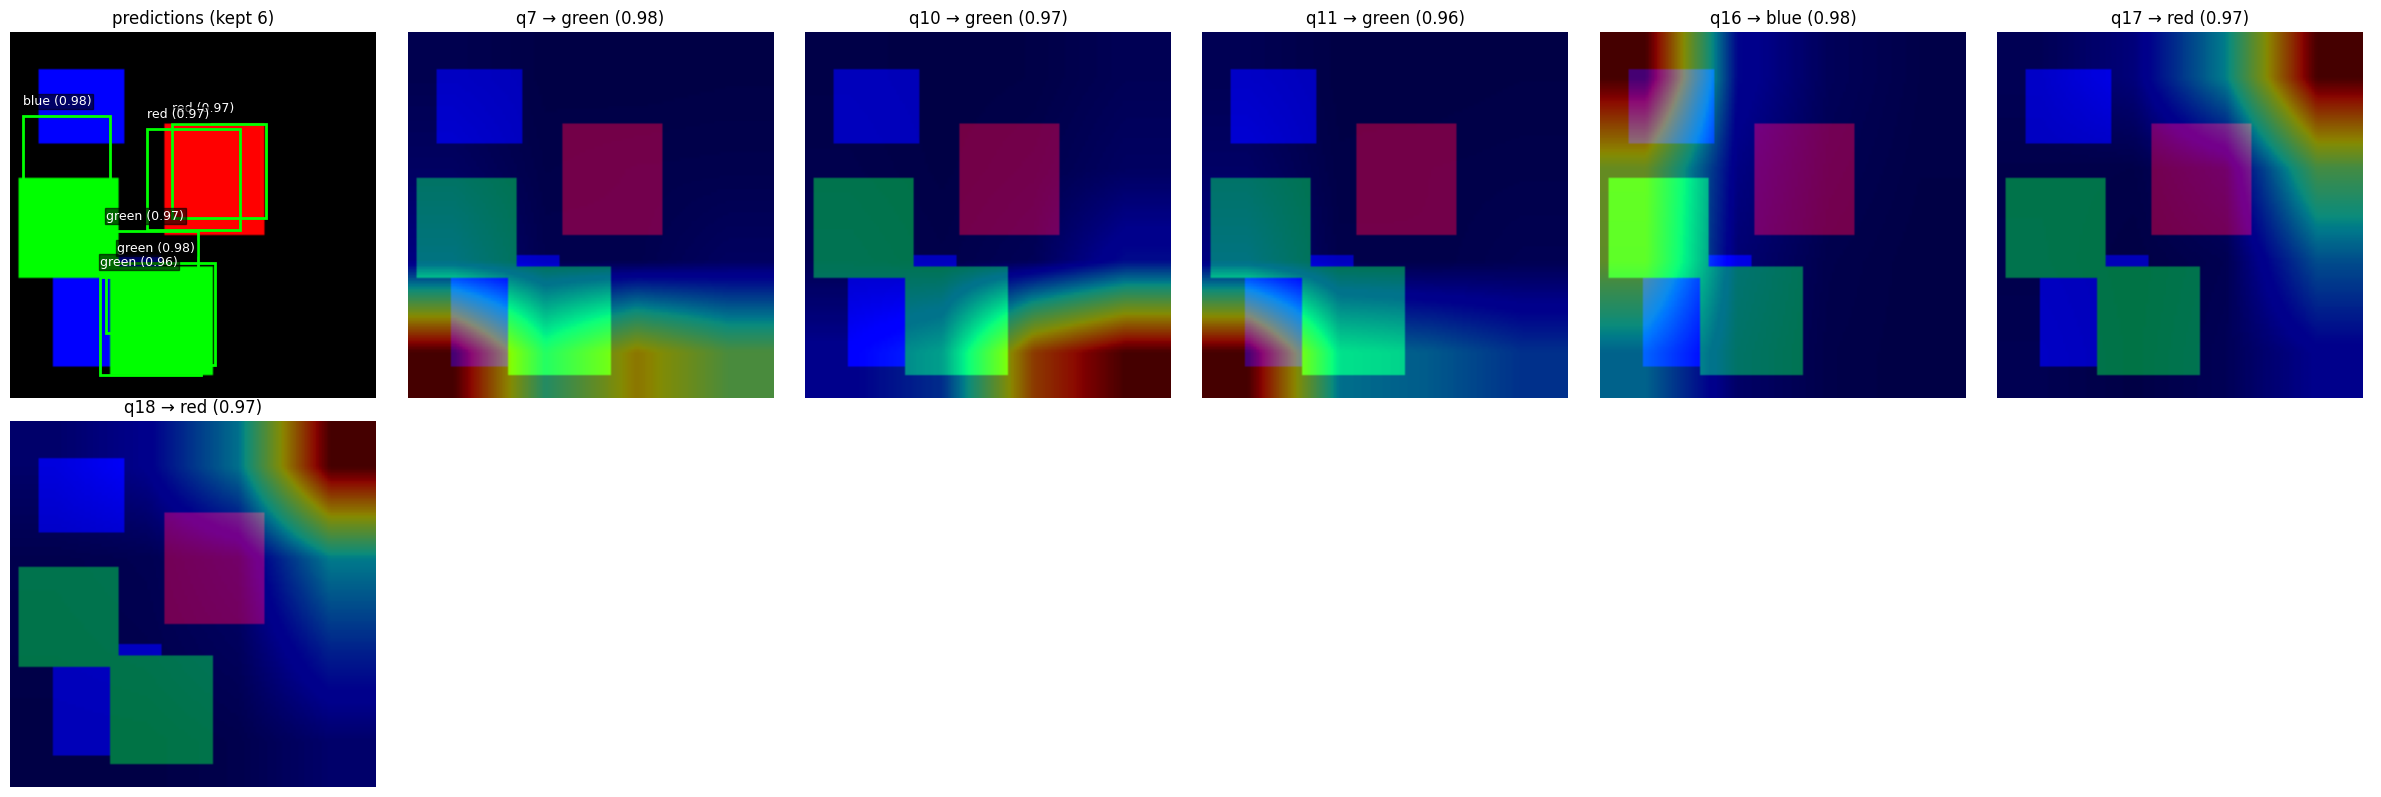

kept 6 predictions; gt had 5 objects


In [609]:
img, tgt = toy_data[2]
result = predict_and_visualize(
    model, img,
    score_threshold=0.96,
    show_attention=True,
    class_names=['no_object', 'red', 'green', 'blue'],
)
print(f"kept {len(result['boxes'])} predictions; gt had {len(tgt['boxes'])} objects")

### Remarks

finding a good model on a simple toy dataset is very slow to train on this vanilla DETR.  I had to train for 5k epochs on 1k images just to get something sensible, and had to play witht he number of queries parameters and the noobj_weight parameters to help the model move away from predicting everything as no-objects. Now, its time to explore what people did after this model to fight the **supervision-sparsity** problem we see here and also the **slow-specialization** problem. 

1. Deformable DETR (Zhu et al. 2020) — restricts each query's cross-attention to a learnable sparse set of keys per query, instead of attending to all spatial tokens. Lets the model focus and converge faster. Also reintroduces multi-scale features that vanilla DETR threw out (which fixes the small-object weakness).
2. DN-DETR (Li 2022) and DINO-DETR (Zhang 2022) — denoising queries, which we already discussed in depth. You should have a very strong intuition here.
3. LW-DETR / RF-DETR — "lightweight" and "refining" variants that combine the above tricks plus query-side improvements (better query initialization, mixed query selection, etc.).

## Exercises / extensions

Once your DETR is training on the toy dataset, try one or two:

1. **Ablate object queries.** Set `num_queries = 1` and re-train. Can it detect anything? What about `num_queries = 10` when the image has 5 objects?
2. **Ablate decoder self-attention.** Remove the self-attention block (keep only cross-attn + FFN). What breaks? (Hint: duplicate detections.)
3. **Ablate auxiliary loss.** Train with loss only on the final layer. Compare convergence speed.
4. **Query specialization plot.** After training, for each query, average the centers of its top predictions across the validation set. Plot the 100 query centers on a 2D plane — you should see specialization (some queries always predict in the top-left, etc.).
5. **Move to Pascal VOC.** Once toy data works, try a real (smaller) detection benchmark.

## End-of-week recap

Write a ≤200-word summary you could send to a colleague who hasn't read the DETR paper. Cover:

1. The conceptual pivot from anchor-based detectors to set prediction.
2. What object queries are and how N → N predictions works.
3. Why bipartite matching is needed and what it gives you.
4. The biggest weakness of vanilla DETR (slow training, ~500 epochs).
5. The one thing you'd want to follow up on.

_..._

---

**Next week (Module 2 / Week 2):** LW-DETR and RF-DETR — building on top of vanilla DETR. Key things to look for: deformable attention (Deformable-DETR), two-stage variants, denoising-based training (DN-DETR / DINO-DETR / RF-DETR), and why these recipes cut training from 500 epochs to ~50.